# 🎯 Expectation Decider

#### 🎰 Importing libraries

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import math
from matplotlib_venn import venn2
import matplotlib.pyplot as plt


#### 💬 Load dataset

In [2]:

df = pd.read_excel("student_dataset.xlsx")
df.head()

,study_hours,attendance,group_discussion,previous_test_score,final_exam_pass
0,8,51,No,61,Fail
1,15,58,Yes,99,Pass
2,6,87,No,34,Fail
3,2,55,Yes,59,Fail
4,33,88,Yes,55,Pass


In [3]:
df.tail()

,study_hours,attendance,group_discussion,previous_test_score,final_exam_pass
445,28,55,No,53,Fail
446,35,68,No,43,Pass
447,6,70,No,69,Fail
448,29,88,No,51,Pass
449,29,72,No,35,Fail


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 450 entries, 0 to 449
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   study_hours          450 non-null    int64 
 1   attendance           450 non-null    int64 
 2   group_discussion     450 non-null    object
 3   previous_test_score  450 non-null    int64 
 4   final_exam_pass      450 non-null    object
dtypes: int64(3), object(2)
memory usage: 17.7+ KB


### 🔢 **Q1. Understanding the Basics**
##### Explain in your own words:


#### 🎲 What is Probability?

##### Probability is a measure of how likely an event is to occur. It ranges from 0 to 1 (or 0% to 100%).
| Probability Value | Meaning |
|------------------|----------|
| 0 | Impossible Event |
| 0.5 | 50% Chance of Occurring |
| 1 | Certain Event |

#### 📖 Key Probability Terminology.

| Term | Meaning |
|------|---------|
| Experiment | An activity that produces outcomes (e.g., observing whether a student passes or fails). |
| Outcome | A possible result of an experiment (Pass or Fail). |
| Event | A collection of outcomes of interest. |
| Sample Space (S) | All possible outcomes. In this dataset: {Pass, Fail}. |
| Probability P(E) | The likelihood that event E occurs. |
| Favorable Outcomes | Outcomes that satisfy the event condition. |
| Independent Events | Events that do not affect each other. |
| Conditional Probability | Probability of an event occurring given another event has occurred. |

#### 📊 Give at least three probability event examples from the dataset.

In [5]:
total_students = len(df)

# Event 1:  (a student passes)

p_pass = len(df[df["final_exam_pass"] == "Pass"]) / total_students
print("Probability of Passing =", p_pass)

# Event 2:  (a student participates in group discussion)

p_group = len(df[df["group_discussion"] == "Yes"]) / total_students
print("Probability of Group Discussion =", p_group)

# Event 3: (a student has attendance greater than 75%)

p_attendance = len(df[df["attendance"] > 75]) / total_students
print("Probability of Attendance > 75% =", p_attendance)

Probability of Passing = 0.6933333333333334
Probability of Group Discussion = 0.4688888888888889
Probability of Attendance > 75% = 0.5022222222222222


### 📋 **Q2. Types of Events**

| Type | Definition |
|------|------------|
| Empirical Probability | Probability calculated using actual observed data or past records. |
| Theoretical Probability | Probability calculated using all possible outcomes, assuming each outcome is equally likely. |

##### 📈 Empirical Probability :- 

In [6]:
total_students = len(df)
pass_students = len(df[df["final_exam_pass"] == "Pass"])

empirical_probability = pass_students / total_students

print("Empirical Probability of Passing =", empirical_probability)

Empirical Probability of Passing = 0.6933333333333334


##### 📐 Theoretical Probability :-

**Scenario   :**   Selecting a student and predicting whether the student is Pass or Fail.(Possible outcomes: S = {Pass, Fail} Number of favorable outcomes for "Pass" = 1           (Total possible outcomes = 2)

In [7]:
theoretical_probability = 1 / 2

print("Theoretical Probability of Passing =", theoretical_probability)

Theoretical Probability of Passing = 0.5


### 🎰 **Q3. Random Variable & Probability Distribution**

#### 🔵 Define the Random Variable

In [ ]:
# Probability of passing from dataset
p = len(df[df["final_exam_pass"] == "Pass"]) / len(df

print("Probability of Passing (p) =", round(p, 4))

Probability of Passing (p) = 0.6933


#### 📊 Construct the Probability Distribution Table

In [9]:
from scipy.stats import binom
p = len(df[df["final_exam_pass"] == "Pass"]) / len(df)

n = 3

distribution = pd.DataFrame({
    "X (Number of Passes)": [0, 1, 2, 3],
    "P(X)": [binom.pmf(x, n, p) for x in range(4)]
})

print(distribution)

   X (Number of Passes)      P(X)
0                     0  0.028840
1                     1  0.195612
2                     2  0.442254
3                     3  0.333293


#### 📏 3. Find the Mean and Variance

In [10]:
mean = n * p
variance = n * p * (1 - p)

print("Mean =", round(mean, 4))
print("Variance =", round(variance, 4))

Mean = 2.08
Variance = 0.6379


#### **Q4 Venn Diagram in Probability**
* Draw a Venn diagram showing:
* Students who study more than 10 hours/week.
* Students who attend more than 80% of classes.
* Overlap showing students who satisfy both conditions.

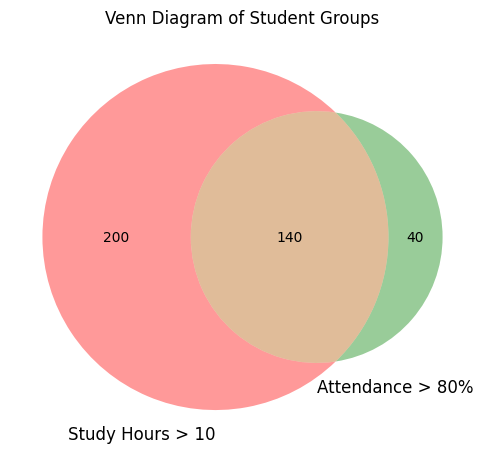

In [11]:
# Set A: (study more than 10 hours/week)
A = set(df[df["study_hours"] > 10].index)

# Set B: (attend more than 80% classes)
B = set(df[df["attendance"] > 80].index)

#Venn Diagram
plt.figure(figsize=(6, 6))
venn2(
    [A, B],
    set_labels=(
        "Study Hours > 10",
        "Attendance > 80%"
    )
)

plt.title("Venn Diagram of Student Groups")
plt.show()

### 📊 **Q5. Contingency Table & Probability Calculations**

#### 📋 Create a contingency table for group_discussion (Yes/No) vs. final_exam_pass (Pass/Fail). From the table, calculate:

In [12]:
contingency_table = pd.crosstab(
    df["group_discussion"],
    df["final_exam_pass"]
)

print(contingency_table)

final_exam_pass   Fail  Pass
group_discussion            
No                  84   155
Yes                 54   157


#### 🔗 Joint probability of “Participates in group discussion AND Passes exam”.

In [13]:
joint_count = len(df[
    (df["group_discussion"] == "Yes") &
    (df["final_exam_pass"] == "Pass")
])

joint_probability = joint_count / len(df)

print("Joint Probability =", joint_probability)

Joint Probability = 0.3488888888888889


#### 📌 Marginal probability of “Passes exam”.

In [14]:
pass_count = len(
    df[df["final_exam_pass"] == "Pass"]
)

marginal_probability = pass_count / len(df)

print("Marginal Probability =", marginal_probability)

Marginal Probability = 0.6933333333333334


#### 🔀 Conditional probability of “Passes exam given participation in group discussion”.

In [15]:
discussion_count = len(
    df[df["group_discussion"] == "Yes"]
)

conditional_probability = (
    joint_count / discussion_count
)

print("Conditional Probability =", conditional_probability)

Conditional Probability = 0.7440758293838863


### 🔍 **Q6. Understanding Relationships**

#### 💬 Interpret conditional probability results in plain language (“intuition” behind the formula).

##### The conditional probability P(Pass∣Group Discussion) tells us the probability that a student passes the exam given that the student participated in group discussions.
##### Plain Language:
* Among students who participated in group discussions, this probability shows how likely they are to pass the final exam.

#### 🧩 Identify if “participating in group discussions” and “passing exam” are independent, dependent, or mutually exclusive events. Justify your answer.

##### Justification:
* Participating in group discussions may affect the chance of passing the exam.
The probability of passing changes when we know whether a student participated in group discussions.
Therefore, the events are dependent.

##### Not Mutually Exclusive:

* A student can both participate in group discussions and pass the exam at the same time.
Therefore, the events are not mutually exclusive.

### 🧮 **Q7. Bayes Theorem Application**
* Suppose historical data shows:
* 70% of students who pass had high attendance (>80%).
* 40% of students who fail also had high attendance.
* 60% of all students had high attendance.
* Use Bayes Theorem to find the probability that a student passed the exam given they had high attendance.

##### 📊 Given Information

* - \( P(H|P) = 0.70 \)
* 70% of students who passed the exam had high attendance (>80%).
* - \( P(H|F) = 0.40 \)
* 40% of students who failed the exam had high attendance (>80%).
* - \( P(H) = 0.60 \)
* 60% of all students had high attendance (>80%).

###### From the dataset:
* \[P(Pass)=\frac{312}{450}=0.6933\]
* \[P(Fail)=\frac{138}{450}=0.3067\]


##### Bayes Theorem Formula

* To find the probability that a student passed the exam given that the student had high attendance:
* \[P(Pass|H)=\frac{P(H|Pass)\times P(Pass)}{P(H)}\]

##### Calculation

* Substituting the given values:

* \[P(Pass|H)=\frac{0.70 \times 0.6933}{0.60}\]
* \[=\frac{0.4853}{0.60}\]
* \[=0.8089\]
* \[=80.89\%\]


##### Final Answer

* \[P(Pass|H)=0.8089\]
* \[P(Pass|H)=80.89\%\]

In [16]:
# Pass and Fail counts from dataset
pass_count = len(df[df["final_exam_pass"] == "Pass"])
fail_count = len(df[df["final_exam_pass"] == "Fail"])
total_students = len(df)

# Given Information
P_H_given_P = 0.70      
P_H = 0.60              

# Probability of Passing from dataset
P_P = pass_count / total_students

# Bayes Theorem
P_P_given_H = (P_H_given_P * P_P) / P_H

print("Pass =", pass_count)
print("Fail =", fail_count)
print("Total =", total_students)

print("\nP(Pass) =", round(P_P, 4))
print("P(Pass | High Attendance) =", round(P_P_given_H, 4))
print("Percentage =", round(P_P_given_H * 100, 2), "%")

Pass = 312
Fail = 138
Total = 450

P(Pass) = 0.6933
P(Pass | High Attendance) = 0.8089
Percentage = 80.89 %
